In [9]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

In [10]:
# ==========================================
# 1. LOAD AND PREPARE THE DATA
# ==========================================
# Make sure the CSV file is in the same directory as your script
df = pd.read_csv('all_stocks_5yr.csv')

# Isolate a single stock to avoid confusing the model with different price scales
stock_df = df[df['Name'] == 'AAPL'].copy()

# Ensure the timeline is strictly chronological
stock_df['date'] = pd.to_datetime(stock_df['date'])
stock_df.sort_values('date', inplace=True)

In [11]:
# ==========================================
# 2. DEFINE THE TARGET VARIABLE
# ==========================================
# 1 if tomorrow's close is higher than today's close (UP). 0 otherwise (DOWN).
stock_df['Target'] = (stock_df['close'].shift(-1) > stock_df['close']).astype(int)

In [12]:
# ==========================================
# 3. FEATURE ENGINEERING (The "Smart" Indicators)
# ==========================================
# Basic Relative Metrics
stock_df['Daily_Return'] = stock_df['close'].pct_change()
stock_df['Volume_Change'] = stock_df['volume'].pct_change()

# Moving Averages
stock_df['5_Day_MA'] = stock_df['close'].rolling(window=5).mean()
stock_df['10_Day_MA'] = stock_df['close'].rolling(window=10).mean()

# Advanced Contextual Metrics
# A. Momentum: Is the short-term trend beating the long-term trend?
stock_df['MA_Crossover'] = stock_df['5_Day_MA'] - stock_df['10_Day_MA']

# B. Overbought/Oversold: How far is the current price from its historical average?
stock_df['Price_to_MA'] = stock_df['close'] / stock_df['10_Day_MA']

# C. Market Panic/Calm: What is the rolling standard deviation of recent returns?
stock_df['Volatility_5d'] = stock_df['Daily_Return'].rolling(window=5).std()

# Drop rows with NaN values created by rolling windows and shifts
stock_df.dropna(inplace=True)

In [13]:
# ==========================================
# 4. SELECT FEATURES AND SPLIT DATA
# ==========================================
# CRITICAL: We explicitly exclude 'open', 'high', 'low', 'close' to prevent non-stationary noise
features = [
    'volume', 'Daily_Return', 'Volume_Change',
    '5_Day_MA', '10_Day_MA', 'MA_Crossover',
    'Price_to_MA', 'Volatility_5d'
]

X = stock_df[features]
y = stock_df['Target']

# Chronological Split (80% Train, 20% Test)
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

In [14]:
# ==========================================
# 5. TRAIN THE RANDOM FOREST
# ==========================================
# We use balanced class weights and specific depth/leaf limits to prevent overfitting
rf_model = RandomForestClassifier(
    n_estimators=200,          # 200 distinct decision trees
    max_depth=10,              # Allow trees to find complex patterns
    min_samples_leaf=10,       # Force generalizability at the ends of the branches
    class_weight='balanced',   # Heavily penalize the model if it ignores the minority class
    random_state=42            # Ensure reproducible results
)

print("Training the Random Forest...\n")
rf_model.fit(X_train, y_train)

Training the Random Forest...



,n_estimators,200
,criterion,'gini'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,10
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [15]:
# ==========================================
# 6. EVALUATE PERFORMANCE
# ==========================================
predictions = rf_model.predict(X_test)

print("Accuracy Score:", round(accuracy_score(y_test, predictions), 4))
print("\nClassification Report:\n", classification_report(y_test, predictions))

Accuracy Score: 0.496

Classification Report:
               precision    recall  f1-score   support

           0       0.49      0.99      0.65       119
           1       0.86      0.05      0.09       131

    accuracy                           0.50       250
   macro avg       0.67      0.52      0.37       250
weighted avg       0.68      0.50      0.36       250



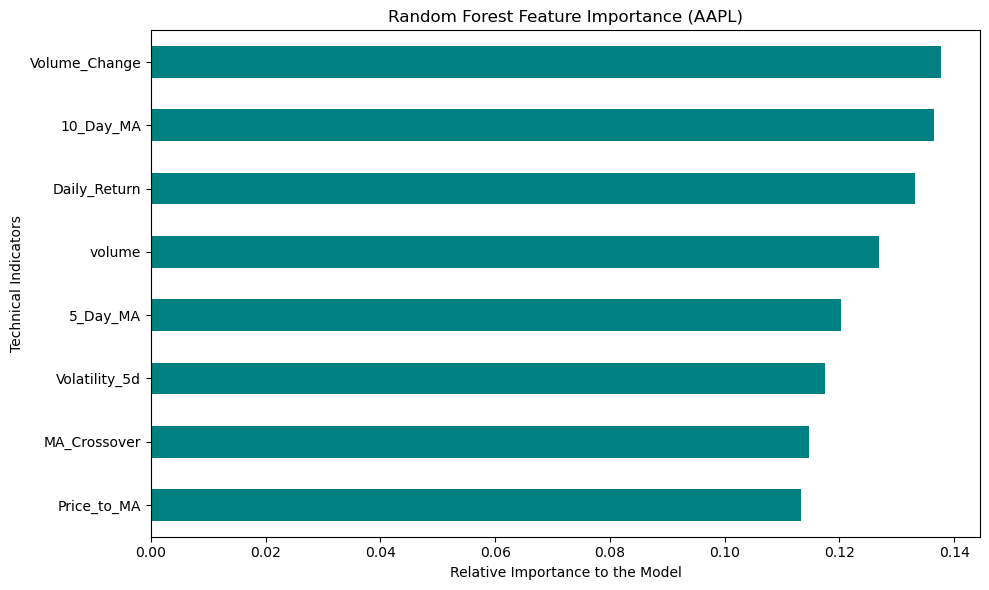

In [16]:
# ==========================================
# 7. VISUALIZE FEATURE IMPORTANCE
# ==========================================
importances = pd.Series(rf_model.feature_importances_, index=features)

plt.figure(figsize=(10, 6))
importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title("Random Forest Feature Importance (AAPL)")
plt.xlabel("Relative Importance to the Model")
plt.ylabel("Technical Indicators")
plt.tight_layout()
plt.show()